In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, random_split

# from model import *
# from dataloader import *

import torch.nn.functional as F
import pathlib

from tqdm import tqdm
import copy
import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [2]:
BATCH_SIZE = 50
train_ratio = 0.8

In [204]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, dataset

import os
import numpy as np

import pathlib

from PIL import Image
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import torch.nn.functional as F


def get_class_map(root):
    class_map = {}
    with open(root / "annotations" / "list.txt") as f:
        for line in f:
            if line.startswith("#"):
                continue
            name, class_id, species, breed_id = line.strip().split()
            class_id = int(class_id) - 1

            # Store mapping (only once per class_id)
            breed_name = "_".join(name.split("_")[:-1])

            if class_id not in class_map:
                class_map[class_id] = breed_name
    return class_map

class OxfordIIITPetDataset(Dataset):
    def __init__(self, root_dir, transforms=None):
        self.root = pathlib.Path(root_dir)
        self.images_dir = self.root / "images"
        self.xml_dir = self.root / "annotations" / "xmls"
        self.trimap_dir = self.root / "annotations" / "trimaps"
        self.transforms = transforms

        self.class_map = {}

        # Read list.txt
        self.samples = []
        with open(self.root / "annotations" / "list.txt") as f:
            for line in f:
                if line.startswith("#"):
                    continue
                name, class_id, species, breed_id = line.strip().split()
                class_id = int(class_id) - 1

                # Store mapping (only once per class_id)
                breed_name = "_".join(name.split("_")[:-1])

                if class_id not in self.class_map:
                    self.class_map[class_id] = breed_name

                img_path = self.images_dir / f"{name}.jpg"
                xml_path = self.xml_dir / f"{name}.xml"
                trimap_path = self.trimap_dir / f"{name}.png"

                if img_path.exists() and xml_path.exists() and trimap_path.exists():
                        self.samples.append({
                            "name": name,
                            "class_id": class_id,
                            "species": int(species),
                            "breed_id": int(breed_id)
                        })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        name = sample["name"]

        # Paths
        img_path = self.images_dir / f"{name}.jpg"
        xml_path = self.xml_dir / f"{name}.xml"
        trimap_path = self.trimap_dir / f"{name}.png"

        # Load image
        image = Image.open(img_path).convert("RGB")
        image = torch.from_numpy(np.array(image)).permute(2, 0, 1)/255.0
        image = F.interpolate(image.unsqueeze(0), [224, 224], mode='bilinear')
        mean = torch.tensor([0.485, 0.456, 0.406], device=image.device).view(3, 1, 1)
        std  = torch.tensor([0.229, 0.224, 0.225], device=image.device).view(3, 1, 1)
        image = (image - mean) / std

        # Load mask
        mask = Image.open(trimap_path)
        mask = np.array(mask)
        mask = (mask != 2).astype(np.float32)
        mask = torch.from_numpy(mask)
        mask = F.interpolate(mask.unsqueeze(0).unsqueeze(0), [224,224], mode='bilinear', align_corners=False)[0]
        mask = mask.unsqueeze(1)

        # Parse XML
        tree = ET.parse(xml_path)
        root = tree.getroot()

        bbox = root.find("object").find("bndbox")
        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)

        orig_w, orig_h = Image.open(img_path).size
        H, W = 224, 224

        xc = (xmin + xmax) / 2 / orig_w
        yc = (ymin + ymax) / 2 / orig_h
        w  = (xmax - xmin) / W
        h  = (ymax - ymin) / H

        bbox = torch.tensor([xc, yc, w, h], dtype=torch.float32)

        scale_x = 224 / orig_w
        scale_y = 224 / orig_h

        xmin_224 = xmin * scale_x
        xmax_224 = xmax * scale_x
        ymin_224 = ymin * scale_y
        ymax_224 = ymax * scale_y

        xc_224 = (xmin_224 + xmax_224) / 2
        yc_224 = (ymin_224 + ymax_224) / 2
        w_224  = (xmax_224 - xmin_224)
        h_224  = (ymax_224 - ymin_224)

        bbox_224 = torch.tensor([xc_224, yc_224, w_224, h_224], dtype=torch.float32)

        if self.transforms:
            image = self.transforms(image)

        return {
            "image": image[0],
            "name": name,
            "bbox": bbox,
            "bbox_224": bbox_224,
            "mask": mask[0],
            "species": sample["species"],   # 1=cat, 2=dog
            "breed": sample["breed_id"],
            "class_id": sample["class_id"],
            "breed_name": self.class_map[sample["class_id"]]
        }

In [205]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset

 
class CustomDropout(nn.Module):
    def __init__(self, p=0.5):
        super().__init__()
        self.p = p
 
    def forward(self, x):
        if not self.training or self.p == 0:
            return x
        mask = (torch.rand(x.shape, device=x.device) > self.p).to(x.dtype)
        mask = mask / ((1 - self.p) + 1e-8)
        return x * mask
 
class VGG11Classifier(nn.Module):
    def __init__(self, num_classes: int = 37, in_channels: int = 3, dropout_p: float = 0.5):
        
        super(VGG11Classifier, self).__init__()
        self.in_channels = in_channels
        self.num_classes = num_classes
        self.dropout_p = dropout_p
 
        self.conv_layers = nn.Sequential(
            nn.Conv2d(self.in_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
 
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
 
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
 
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
 
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
 
        self.linear_layers = nn.Sequential(
            nn.Linear(in_features=512 * 7 * 7, out_features=4096),
            nn.ReLU(),
            CustomDropout(p=dropout_p),
            nn.Linear(in_features=4096, out_features=4096),
            nn.ReLU(),
            CustomDropout(p=dropout_p),
            nn.Linear(in_features=4096, out_features=self.num_classes)
        )
 
    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.linear_layers(x)
        return x
 

In [206]:
import torch
from torch import nn

class IoULoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, pred, target):
        # pred, target: [B, 4] -> (xc, yc, w, h)

        # Convert to corners
        pred_x1 = pred[:, 0] - pred[:, 2] / 2
        pred_y1 = pred[:, 1] - pred[:, 3] / 2
        pred_x2 = pred[:, 0] + pred[:, 2] / 2
        pred_y2 = pred[:, 1] + pred[:, 3] / 2

        target_x1 = target[:, 0] - target[:, 2] / 2
        target_y1 = target[:, 1] - target[:, 3] / 2
        target_x2 = target[:, 0] + target[:, 2] / 2
        target_y2 = target[:, 1] + target[:, 3] / 2

        # Intersection
        x1 = torch.max(pred_x1, target_x1)
        y1 = torch.max(pred_y1, target_y1)
        x2 = torch.min(pred_x2, target_x2)
        y2 = torch.min(pred_y2, target_y2)

        inter = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)

        # Areas
        pred_area = (pred_x2 - pred_x1) * (pred_y2 - pred_y1)
        target_area = (target_x2 - target_x1) * (target_y2 - target_y1)

        union = pred_area + target_area - inter + 1e-6

        iou = inter / union

        return 1 - iou.mean()

In [207]:
class VGG11_Localizer(nn.Module):
    def __init__(self, backbone):
        super().__init__()

        self.backbone = backbone

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 1024),
            nn.ReLU(),
            nn.Linear(1024, 4),
            nn.Sigmoid()  # ensures output in [0,1]
        )

    def forward(self, x):
        x = self.backbone(x)
        bbox = self.regressor(x)
        return bbox

In [208]:
dataset = OxfordIIITPetDataset(root_dir = "oxford-iiit-pet")
len(dataset)

3671

In [209]:
dataset = OxfordIIITPetDataset(root_dir = "oxford-iiit-pet")

train_ds, test_ds = random_split(dataset, [int(train_ratio * len(dataset)), len(dataset)-int(train_ratio * len(dataset))])

train_dl = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size = BATCH_SIZE, shuffle=False)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_classifier = VGG11Classifier(num_classes=37, in_channels=3)
checkpoint = torch.load("vgg11_pet_model_30_epochs.pth", map_location=device)

model_classifier.load_state_dict(checkpoint['model_state_dict'])
model_classifier.to(device)
model_classifier.eval()

model_localizer = VGG11_Localizer(copy.deepcopy(model_classifier.conv_layers))
checkpoint = torch.load("vgg11_pet_model_localizer_30_epochs.pth", map_location=device)

model_localizer.load_state_dict(checkpoint['model_state_dict'])
model_localizer.to(device)
model_localizer.eval()

VGG11_Localizer(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, di

In [10]:
mappings = get_class_map(pathlib.Path("oxford-iiit-pet"))

Actual:    Ragdoll
Predicted: Ragdoll
0.5730708 0.27889028 0.9050659 0.89634883


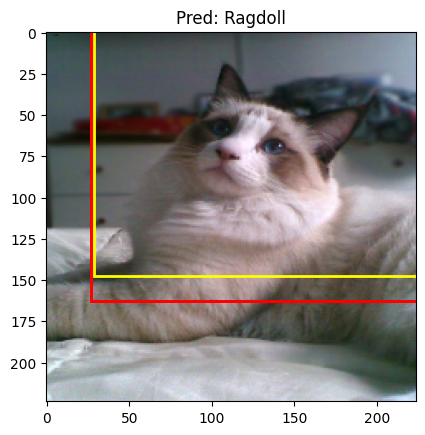

In [11]:
idx = 0
model_classifier.eval()
sample = next(iter(train_dl))
sample_image = sample['image'][idx]
sample_bbox = sample['bbox'][idx]
sample_class_id = sample['class_id'][idx]

sample_pred_logits = model_classifier(sample_image.unsqueeze(0))
sample_preds = torch.softmax(sample_pred_logits, dim = 1)
sample_class_id_pred = torch.argmax(sample_preds)

print(f"Actual:    {mappings[sample_class_id.item()]}")
print(f"Predicted: {mappings[sample_class_id_pred.item()]}")

sample_bbox_pred = model_localizer(sample_image.unsqueeze(0))
sample_numpy_image = sample_image.permute(1,2,0).detach().cpu().numpy()

mean = torch.tensor([0.485, 0.456, 0.406], device=sample_image.device).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225], device=sample_image.device).view(3, 1, 1)
sample_image = sample_image * std + mean
sample_numpy_image = sample_image.permute(1,2,0).detach().cpu().numpy()

H, W, _ = sample_numpy_image.shape

x, y, w, h = sample_bbox_pred.squeeze().detach().cpu().numpy()
print(x, y, w, h)

# normalized -> pixel
x = x * W
y = y * H
w = w * W
h = h * H

# center -> top-left
x = x - w/2
y = y - h/2

fig, ax = plt.subplots(1)

ax.imshow(sample_numpy_image)

# Predicted bbox (RED)
rect_pred = patches.Rectangle(
    (x, y), w, h,
    linewidth=2, edgecolor='r', facecolor='none'
)
ax.add_patch(rect_pred)


# Predicted bbox (RED)
rect_pred = patches.Rectangle(
    (x, y), w, h,
    linewidth=2, edgecolor='r', facecolor='none'
)
ax.add_patch(rect_pred)

# actual bbox (YELLOW)
xc, yc, w_gt, h_gt = sample_bbox.cpu().numpy()

x_gt = xc * W
y_gt = yc * H
w_gt = w_gt * W
h_gt = h_gt * H

# center -> top-left
x_gt = x_gt - w_gt/2
y_gt = y_gt - h_gt/2

rect_gt = patches.Rectangle(
    (x_gt, y_gt), w_gt, h_gt,
    linewidth=2, edgecolor='Yellow', facecolor='none'
)

ax.add_patch(rect_gt)

plt.title(f"Pred: {mappings[sample_class_id_pred.item()]}")
plt.show()


In [ ]:
# correct = 0
# total = 0

# for sample in test_dl:
#     num = sample['image'].shape[0]
#     total += num
#     for idx in range(num):
#         sample_image = sample['image'][idx]
#         sample_class_id = sample['class_id'][idx]

#         sample_pred_logits = model_classifier(sample_image.unsqueeze(0))

#         sample_preds = torch.softmax(sample_pred_logits, dim = 1)
#         sample_class_id_pred = torch.argmax(sample_preds)

#         print(f"actual   : {sample_class_id} | {mappings[sample_class_id.item()]}")
#         print(f"predicted: {sample_class_id_pred} | {mappings[sample_class_id_pred.item()]}\n")

#         if sample_class_id == sample_class_id_pred:
#             correct += 1

actual   : 30 | scottish_terrier
predicted: 30 | scottish_terrier

actual   : 35 | wheaten_terrier
predicted: 35 | wheaten_terrier

actual   : 16 | havanese
predicted: 13 | english_setter

actual   : 10 | chihuahua
predicted: 10 | chihuahua

actual   : 25 | pug
predicted: 25 | pug

actual   : 11 | Egyptian_Mau
predicted: 36 | yorkshire_terrier

actual   : 0 | Abyssinian
predicted: 0 | Abyssinian

actual   : 16 | havanese
predicted: 19 | leonberger

actual   : 7 | Bombay
predicted: 7 | Bombay

actual   : 9 | British_Shorthair
predicted: 9 | British_Shorthair

actual   : 4 | beagle
predicted: 4 | beagle

actual   : 1 | american_bulldog
predicted: 1 | american_bulldog

actual   : 31 | shiba_inu
predicted: 31 | shiba_inu

actual   : 8 | boxer
predicted: 8 | boxer

actual   : 15 | great_pyrenees
predicted: 15 | great_pyrenees

actual   : 32 | Siamese
predicted: 32 | Siamese

actual   : 9 | British_Shorthair
predicted: 9 | British_Shorthair

actual   : 28 | saint_bernard
predicted: 28 | sain

KeyboardInterrupt: 

In [57]:
class VGG11_Encoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(2,2)

        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.pool2 = nn.MaxPool2d(2,2)

        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.pool3 = nn.MaxPool2d(2,2)

        self.block4 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        self.pool4 = nn.MaxPool2d(2,2)

        self.block5 = nn.Sequential(
            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        self.pool5 = nn.MaxPool2d(2,2)

    def forward(self, x):
        x1 = self.block1(x)   # 224
        x2 = self.block2(self.pool1(x1))  # 112
        x3 = self.block3(self.pool2(x2))  # 56
        x4 = self.block4(self.pool3(x3))  # 28
        x5 = self.block5(self.pool4(x4))  # 14
        x6 = self.pool5(x5)               # 7

        return x1, x2, x3, x4, x5, x6

In [ ]:
# classifier_old = VGG11Classifier() # fix this
encoder_new    = VGG11_Encoder()

In [122]:
def copy_weights(old_seq, new_blocks):
    old_layers = list(old_seq.children())

    idx = 0
    for block in new_blocks:
        for layer in block:
            if isinstance(layer, (nn.Conv2d, nn.BatchNorm2d)):
                layer.weight.data = old_layers[idx].weight.data.clone()
                layer.bias.data   = old_layers[idx].bias.data.clone()
                idx += 1
            elif isinstance(layer, nn.ReLU):
                idx += 1  # skip ReLU
        idx += 1  # skip MaxPool


copy_weights(model_classifier.conv_layers, [
    encoder_new.block1,
    encoder_new.block2,
    encoder_new.block3,
    encoder_new.block4,
    encoder_new.block5
])

In [65]:
class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

        self.conv = nn.Sequential(
            nn.Conv2d(out_channels + skip_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)  # feature fusion
        x = self.conv(x)
        return x

In [202]:
class VGG11_UNet(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()

        self.encoder = VGG11_Encoder()

        self.up1 = UpBlock(512, 512, 512)  # 7   -> 14
        self.up2 = UpBlock(512, 512, 256)  # 14  -> 28
        self.up3 = UpBlock(256, 256, 128)  # 28  -> 56
        self.up4 = UpBlock(128, 128, 64)   # 56  -> 112
        self.up5 = UpBlock(64, 64, 64)     # 112 -> 224

        self.final = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        x1, x2, x3, x4, x5, x6 = self.encoder(x)

        x = self.up1(x6, x5)
        x = self.up2(x, x4)
        x = self.up3(x, x3)
        x = self.up4(x, x2)
        x = self.up5(x, x1)

        return self.final(x)
    
unet = VGG11_UNet(num_classes = 1) # background, subject etc
unet(torch.rand(5, 3, 224, 224)).shape

torch.Size([5, 1, 224, 224])

In [68]:
class DiceLoss(nn.Module):
    def forward(self, pred, target):
        pred = torch.sigmoid(pred)

        intersection = (pred * target).sum()
        union = pred.sum() + target.sum()

        dice = (2. * intersection + 1e-6) / (union + 1e-6)

        return 1 - dice

In [121]:
bce = nn.BCEWithLogitsLoss()

def loss_fn(pred, target):
    return bce(pred, target) + DiceLoss()(pred, target)

pred = torch.randn(1, 1, 224, 224)   # logits
target = (torch.rand(1, 1, 224, 224) > 0.4).float()

loss_fn(target, target)

tensor(0.7569)

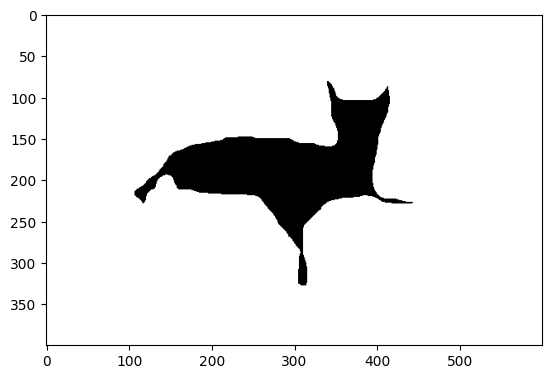

In [160]:
img = plt.imread("oxford-iiit-pet/annotations/trimaps/Abyssinian_1.png")
border = 1-((img < 0.01) * 1.)
background = 1-((img < 0.007) * 1.)
object = ((img < 0.007) * 1.)
plt.imshow(background, cmap = "gray")

In [211]:
next(iter(train_dl))["mask"].shape

torch.Size([50, 1, 224, 224])

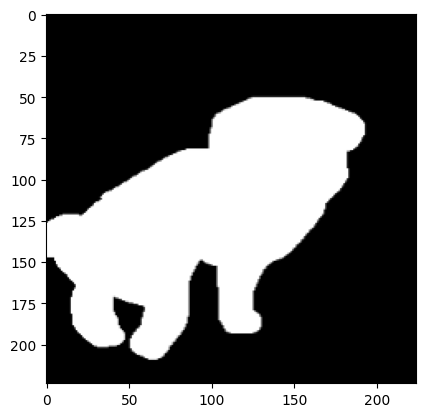

In [199]:
mask = next(iter(train_dl))["mask"][0]
plt.imshow(mask, cmap = "gray")

In [185]:
"maskmask = Image.open("oxford-iiit-pet/annotations/trimaps/Abyssinian_1.png")
mask = np.array(mask)
mask = (mask != 2).astype(np.float32)
plt.imshow(mask, cmap = "gray")

SyntaxError: unterminated string literal (detected at line 1) (2580087739.py, line 1)